# Libraries

In [14]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Read dataset

In [ ]:
filename = 'dataset_1.pkl'
with open(filename, 'rb') as f:
    dataset = pickle.load(f)
x = dataset[1].copy()

In [52]:
y = pd.read_excel('data_models_rv2.xlsx', sheet_name="Modelos")
y = y["Output: w_exp (mm)"].to_frame()
y

,Output: w_exp (mm)
0,0.16
1,0.23
2,0.24
3,0.27
4,0.35
...,...
336,0.19
337,0.22
338,0.17
339,0.19


In [16]:
x = x[['diametro_da_armadura_mm', 'resistencia_do_aco_fy_mpa',
       'numero_de_barras_em_uma_camada', 'espacamento_entre_as_barras_mm',
       'resistencia_a_tracao_do_concreto_mpa', 'cobrimento_mm',
       'distancia_ao_centro_de_gravidade_da_armadura_mm',
       'largura_da_viga_b_mm', 'altura_da_viga_h_mm',
       'area_de_aco_tracionada_as_mm2', 'taxa_de_armadura_conforme_mc2020',
       'momento_fletor_ms_knm']]
x

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,momento_fletor_ms_knm
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,20.800
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,27.300
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,28.200
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,32.600
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,41.200
...,...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,0.046242,149.268
337,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,0.046242,168.882
338,35.8,276,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,0.067478,167.034
339,35.8,276,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,0.067478,130.788


# Scaler Dataset

In [17]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,momento_fletor_ms_knm
0,0.339092,0.313351,-0.361535,1.331304,2.058418,-0.729157,-0.396408,0.128374,-1.224080,-0.090056,-0.291862,-0.590051
1,0.339092,0.313351,-0.361535,1.331304,2.058418,-0.729157,-0.396408,0.128374,-1.224080,-0.090056,-0.291862,-0.478976
2,0.339092,0.313351,-0.361535,1.331304,2.058418,-0.729157,-0.396408,0.128374,-1.224080,-0.090056,-0.291862,-0.463596
3,0.339092,0.313351,-0.361535,1.331304,2.058418,-0.729157,-0.396408,0.128374,-1.224080,-0.090056,-0.291862,-0.388407
4,0.339092,0.313351,-0.361535,1.331304,2.058418,-0.729157,-0.396408,0.128374,-1.224080,-0.090056,-0.291862,-0.241446
...,...,...,...,...,...,...,...,...,...,...,...,...
336,1.731340,-1.880306,-0.361535,-0.283832,-1.027005,0.478951,0.694111,-0.479658,2.208868,1.042249,1.323203,1.605272
337,1.731340,-1.880306,-0.361535,-0.283832,-1.027005,0.478951,0.694111,-0.479658,2.208868,1.042249,1.323203,1.940445
338,2.867543,-1.880306,-0.361535,-0.588009,-1.084452,0.478951,0.989289,-0.479658,2.208868,2.277180,2.698306,1.908865
339,2.867543,-1.880306,-0.361535,-0.588009,-0.667660,0.478951,0.989289,-0.479658,2.208868,2.277180,2.698306,1.289476


# PCA

### Train

In [ ]:
pca = PCA(n_components=4, random_state=42)
pca.fit(x_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)

PCA(n_components=4, random_state=42)

Explained variance ratio: [0.31624676 0.19434472 0.18179437 0.10411846]


### PCA components

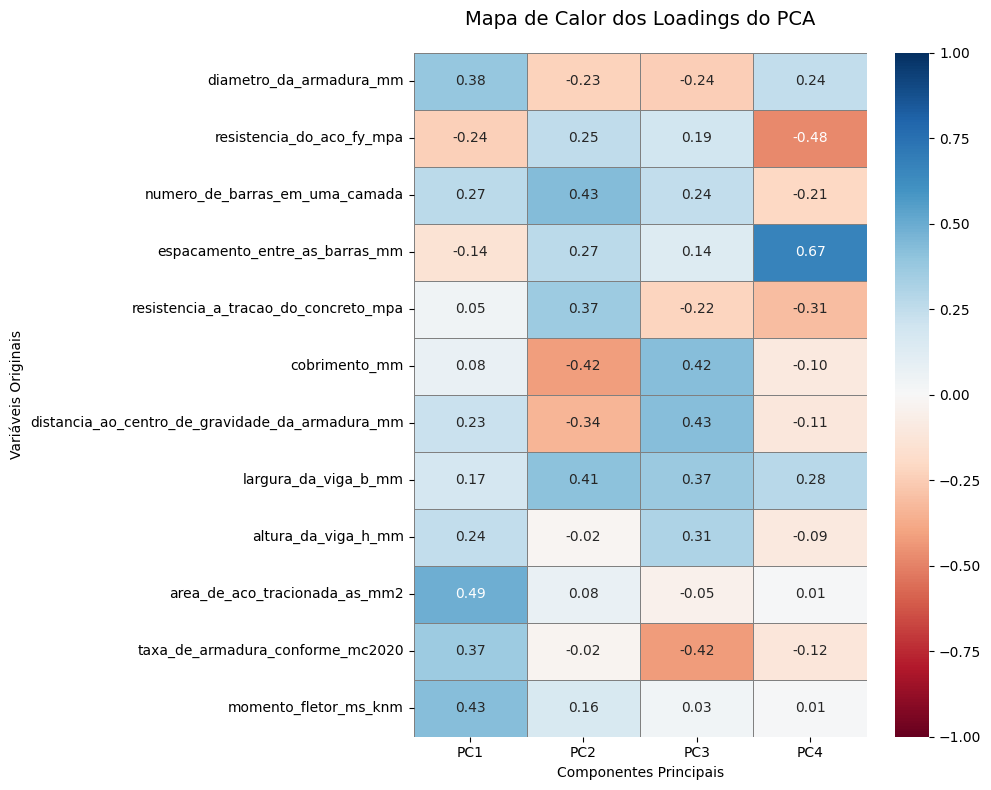

In [48]:
loadings = pd.DataFrame(
    pca.components_.T,  # Transpor: variáveis nas linhas, PCs nas colunas
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=x_scaled.columns if hasattr(x_scaled, 'columns') else [f'Var_{i}' for i in range(x_scaled.shape[1])]
)

import seaborn as sns

# 2. Heatmap dos loadings
plt.figure(figsize=(10, 8))
sns.heatmap(
    loadings,
    annot=True,  # Mostra os valores nas células
    fmt=".2f",   # Formato com 2 casas decimais
    cmap='RdBu', # Mapa de cores divergente (azul-negativo, vermelho-positivo)
    center=0,    # Centralizar em 0
    vmin=-1, vmax=1,  # Loadings variam tipicamente entre -1 e 1
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Mapa de Calor dos Loadings do PCA', fontsize=14, pad=20)
plt.xlabel('Componentes Principais')
plt.ylabel('Variáveis Originais')
plt.tight_layout()
plt.show()


### Component 0

In [34]:
plt.scatter(pca[:, 0], pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.show()

TypeError: 'PCA' object is not subscriptable

### Chart PCA

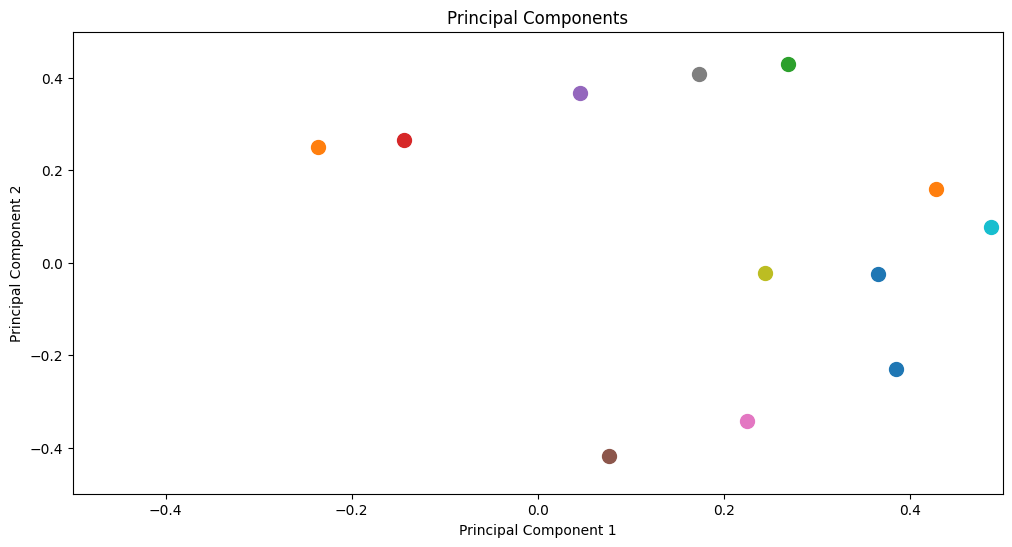

In [21]:
import matplotlib.pyplot as plt

# Plot principal components
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
for i, (x, y) in enumerate(zip(pca.components_[0], pca.components_[1])):
    ax.scatter(x, y, marker='o', s=100)
    # ax.annotate(returns.columns[i], xy=(x, y), xytext=(x+0.04, y+0.06),
    #             arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=6, headlength=8, connectionstyle='arc3,rad=0.1'))

ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('Principal Components')
plt.show()

Colunas encontradas no dataset:
Index(['Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
       'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
       'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
       'Distância ao centro de gravidade da armadura  (mm)',
       'Largura da viga - b (mm)', 'Altura da viga - h (mm)',
       'Área de aço tracionada - As (mm2)', 'Taxa de armadura conforme MC2020',
       'Momento fletor - Ms (kNm)', 'Output: w_exp (mm)'],
      dtype='object')

Formato de X: (341, 12)
Formato de y: (341,)

Variância explicada por componente (PCA): [0.31624676 0.19434472]
Variância total explicada (2 PCs): 0.5105914820043366


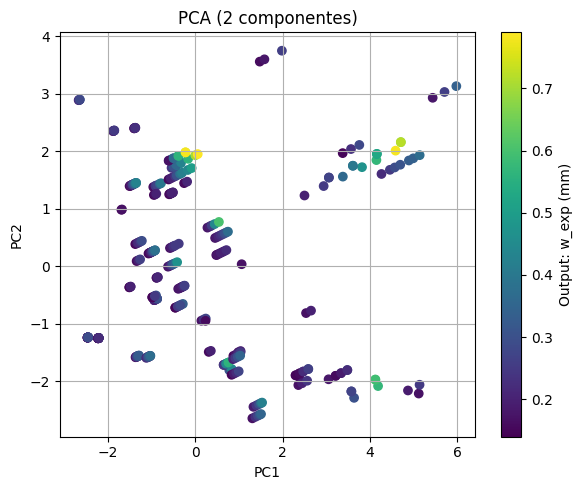

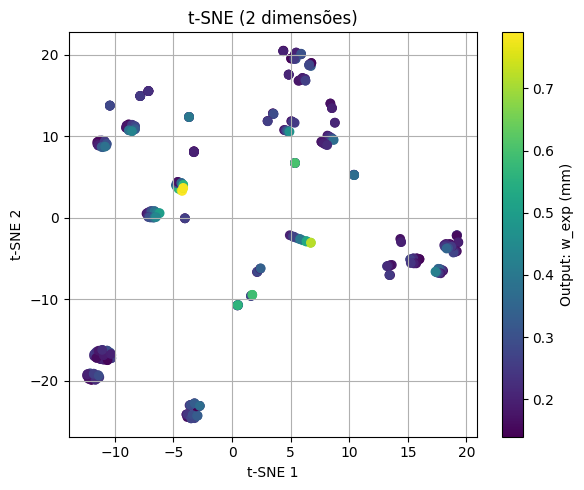


Arquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.


In [10]:
print("Colunas encontradas no dataset:")
print(df.columns)

# Separa X e y
y = df[NOME_COLUNA_ALVO]
X = df.drop(columns=[NOME_COLUNA_ALVO])

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

# ==============================
# 3. Padronização dos dados (média 0, desvio 1)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4. PCA (redução para 2 componentes)
# ==============================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nVariância explicada por componente (PCA):", pca.explained_variance_ratio_)
print("Variância total explicada (2 PCs):", pca.explained_variance_ratio_.sum())

# Plot PCA em 2D
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 componentes)")
cbar = plt.colorbar(scatter)
cbar.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 5. t-SNE (redução para 2 dimensões)
# ==============================
# t-SNE é mais pesado; para datasets muito grandes, pode demorar.
tsne = TSNE(
    n_components=2,
    perplexity=30,      # ajuste fino se necessário
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE em 2D
plt.figure()
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="viridis")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (2 dimensões)")
cbar_tsne = plt.colorbar(scatter_tsne)
cbar_tsne.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 6. Salvar resultados em Excel (opcional)
# ==============================
# Adiciona as colunas de PCA e t-SNE ao DataFrame original
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]
df["TSNE1"] = X_tsne[:, 0]
df["TSNE2"] = X_tsne[:, 1]

df.to_excel("resultado_pca_tsne.xlsx", index=False)
print("\nArquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.")



=== LOADINGS DO PCA ===
                                                         PC1       PC2
Diâmetro da armadura (mm)                           0.750833 -0.353461
Resistência do aço - fy (MPa)                      -0.460573  0.383243
Número de barras em uma camada                      0.525160  0.659090
Espaçamento entre as barras (mm)                   -0.280762  0.406877
Resistência à tração do concreto (MPa)              0.089163  0.560995
Cobrimento (mm)                                     0.150061 -0.638368
Distância ao centro de gravidade da armadura  (mm)  0.439601 -0.525523
Largura da viga - b (mm)                            0.339112  0.625967
Altura da viga - h (mm)                             0.477440 -0.034791
Área de aço tracionada - As (mm2)                   0.949967  0.119384
Taxa de armadura conforme MC2020                    0.712721 -0.038084
Momento fletor - Ms (kNm)                           0.835795  0.245125

=== FEATURES ORDENADAS POR IMPORTÂNCIA (PCA) ===
  

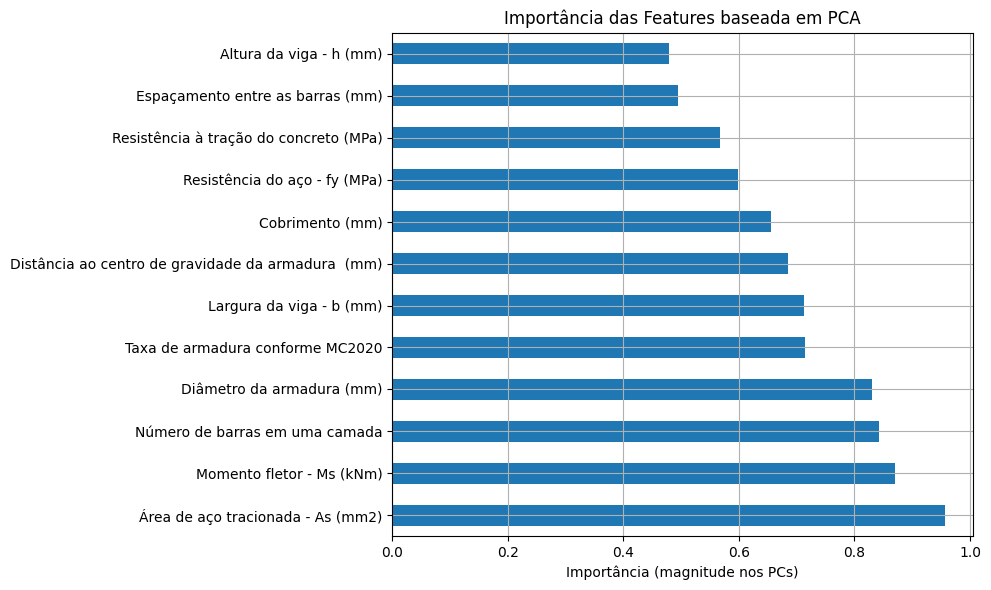

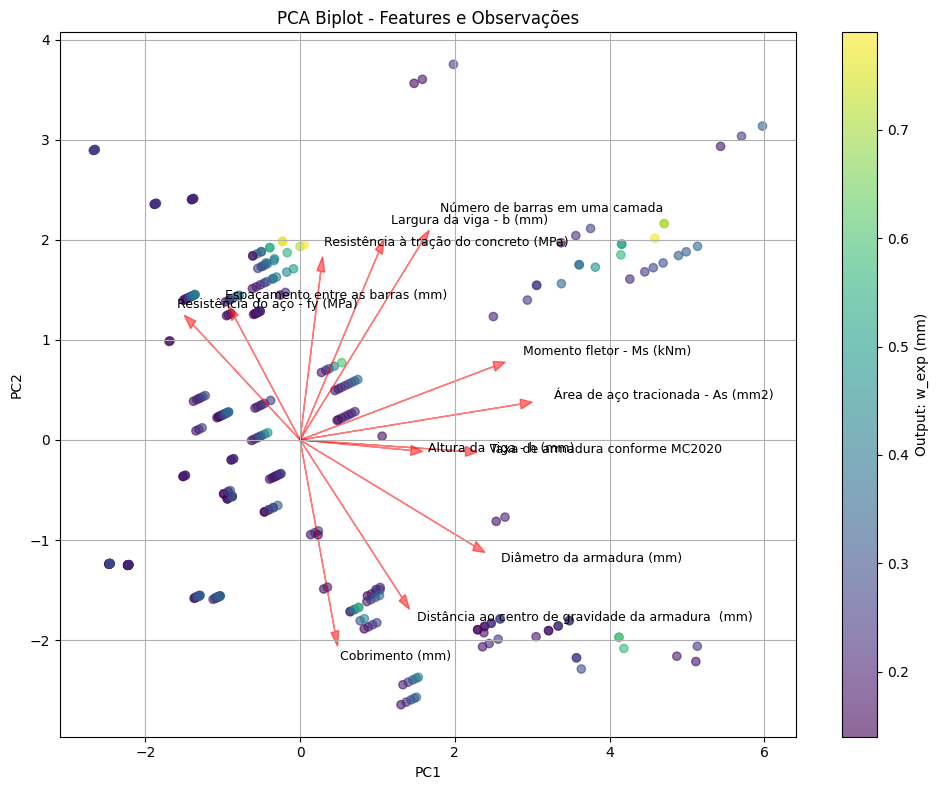

In [11]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\n=== LOADINGS DO PCA ===")
print(loadings_df)

loadings_df['Importancia_Total'] = np.sqrt(loadings_df['PC1']**2 + loadings_df['PC2']**2)
loadings_df_sorted = loadings_df.sort_values('Importancia_Total', ascending=False)

print("\n=== FEATURES ORDENADAS POR IMPORTÂNCIA (PCA) ===")
print(loadings_df_sorted)

plt.figure(figsize=(10, 6))
loadings_df_sorted['Importancia_Total'].plot(kind='barh')
plt.xlabel('Importância (magnitude nos PCs)')
plt.title('Importância das Features baseada em PCA')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)

scale_factor = 3 
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, 
              loadings[i, 0] * scale_factor, 
              loadings[i, 1] * scale_factor,
              color='r', alpha=0.5, head_width=0.1)
    plt.text(loadings[i, 0] * scale_factor * 1.15, 
             loadings[i, 1] * scale_factor * 1.15,
             feature, fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot - Features e Observações')
plt.colorbar(label=NOME_COLUNA_ALVO)
plt.grid(True)
plt.tight_layout()
plt.show()


=== CORRELAÇÃO DAS FEATURES COM OS PCs ===
                                                    Corr_PC1  Corr_PC2  \
Área de aço tracionada - As (mm2)                   0.948573  0.119209   
Momento fletor - Ms (kNm)                           0.834568  0.244765   
Diâmetro da armadura (mm)                           0.749731 -0.352942   
Taxa de armadura conforme MC2020                    0.711675 -0.038029   
Número de barras em uma camada                      0.524390  0.658123   
Cobrimento (mm)                                     0.149841 -0.637431   
Largura da viga - b (mm)                            0.338615  0.625048   
Resistência à tração do concreto (MPa)              0.089032  0.560172   
Distância ao centro de gravidade da armadura  (mm)  0.438956 -0.524752   
Altura da viga - h (mm)                             0.476740 -0.034740   
Resistência do aço - fy (MPa)                      -0.459897  0.382680   
Espaçamento entre as barras (mm)                   -0.280350  0.4062

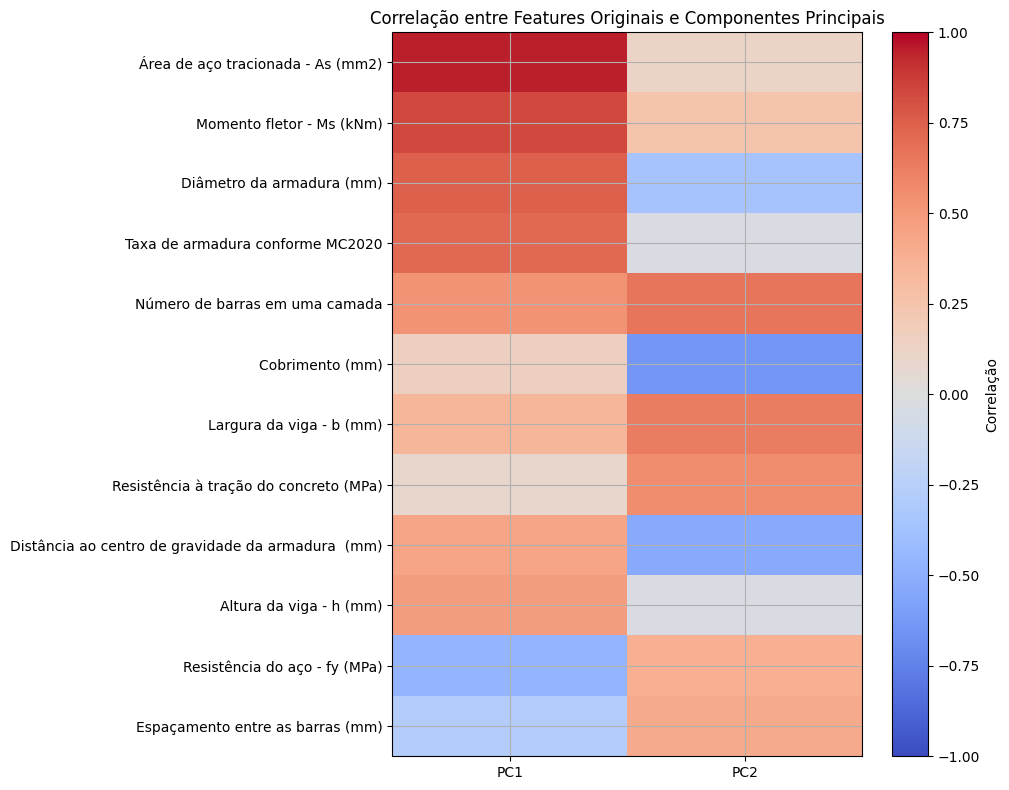

In [12]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

correlacoes = pd.DataFrame(index=X.columns, columns=['Corr_PC1', 'Corr_PC2'])

for col in X.columns:
    correlacoes.loc[col, 'Corr_PC1'] = np.corrcoef(X[col], X_pca[:, 0])[0, 1]
    correlacoes.loc[col, 'Corr_PC2'] = np.corrcoef(X[col], X_pca[:, 1])[0, 1]

correlacoes = correlacoes.astype(float)
correlacoes['Corr_Abs_Max'] = correlacoes.abs().max(axis=1)
correlacoes_sorted = correlacoes.sort_values('Corr_Abs_Max', ascending=False)

print("\n=== CORRELAÇÃO DAS FEATURES COM OS PCs ===")
print(correlacoes_sorted)

plt.figure(figsize=(10, 8))
plt.imshow(correlacoes_sorted[['Corr_PC1', 'Corr_PC2']].values, 
           aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlação')
plt.yticks(range(len(correlacoes_sorted)), correlacoes_sorted.index)
plt.xticks([0, 1], ['PC1', 'PC2'])
plt.title('Correlação entre Features Originais e Componentes Principais')
plt.tight_layout()
plt.show()


=== CORRELAÇÃO DIRETA COM Output: w_exp (mm) ===
Momento fletor - Ms (kNm)                             0.526232
Largura da viga - b (mm)                              0.325865
Altura da viga - h (mm)                               0.299277
Número de barras em uma camada                        0.288969
Área de aço tracionada - As (mm2)                     0.213889
Resistência do aço - fy (MPa)                         0.170688
Distância ao centro de gravidade da armadura  (mm)    0.167820
Diâmetro da armadura (mm)                             0.026775
Espaçamento entre as barras (mm)                      0.016295
Cobrimento (mm)                                      -0.010800
Taxa de armadura conforme MC2020                     -0.024022
Resistência à tração do concreto (MPa)               -0.072067
dtype: float64


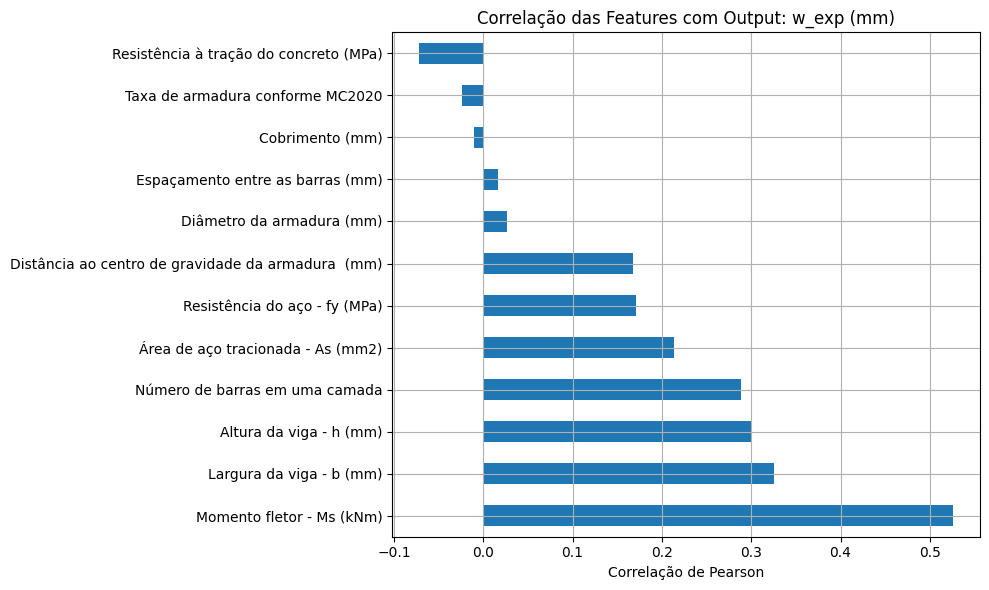

In [13]:
# ==============================
# Correlação direta com o target
# ==============================

correlacao_target = X.corrwith(y).sort_values(ascending=False)

print("\n=== CORRELAÇÃO DIRETA COM", NOME_COLUNA_ALVO, "===")
print(correlacao_target)

plt.figure(figsize=(10, 6))
correlacao_target.plot(kind='barh')
plt.xlabel('Correlação de Pearson')
plt.title(f'Correlação das Features com {NOME_COLUNA_ALVO}')
plt.tight_layout()
plt.show()


=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
                                              Feature  Importance
11                          Momento fletor - Ms (kNm)    0.432769
8                             Altura da viga - h (mm)    0.135103
2                      Número de barras em uma camada    0.083420
10                   Taxa de armadura conforme MC2020    0.071904
5                                     Cobrimento (mm)    0.067656
4              Resistência à tração do concreto (MPa)    0.053698
3                    Espaçamento entre as barras (mm)    0.049067
6   Distância ao centro de gravidade da armadura  ...    0.034511
9                   Área de aço tracionada - As (mm2)    0.023303
7                            Largura da viga - b (mm)    0.019970
1                       Resistência do aço - fy (MPa)    0.019072
0                           Diâmetro da armadura (mm)    0.009527


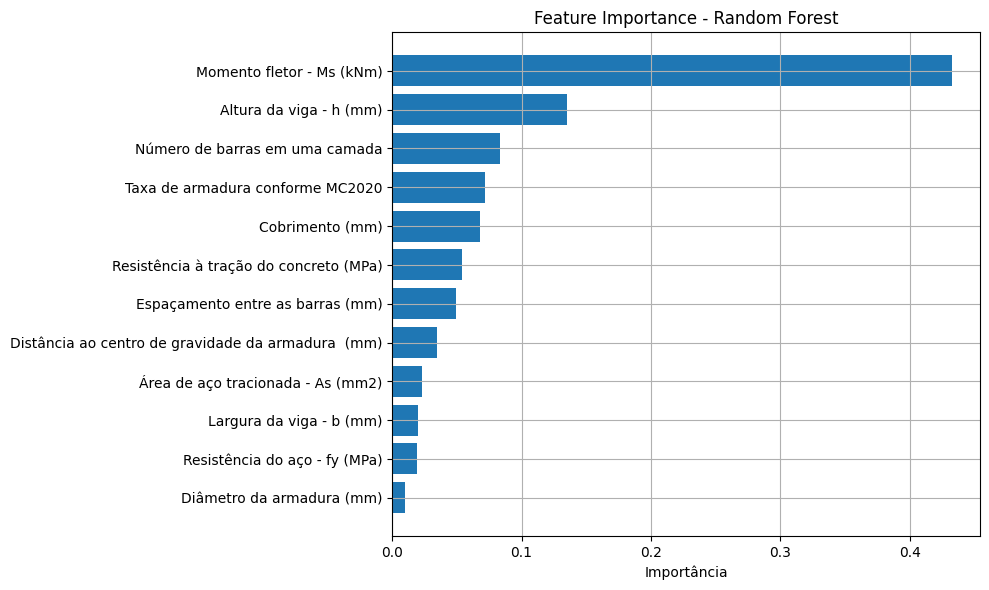

In [14]:
from sklearn.ensemble import RandomForestRegressor

# ==============================
# Feature Importance com Random Forest
# ==============================

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

# Importâncias
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importância')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# ==============================
# ANÁLISES ADICIONAIS PARA t-SNE
# ==============================

print("\n" + "="*60)
print("ANÁLISES PARA t-SNE")
print("="*60)

# ==============================
# 1. Correlação das features originais com as dimensões do t-SNE
# ==============================
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
correlacoes_tsne = pd.DataFrame(index=X.columns, columns=['Corr_TSNE1', 'Corr_TSNE2'])

for col in X.columns:
    correlacoes_tsne.loc[col, 'Corr_TSNE1'] = np.corrcoef(X[col], X_tsne[:, 0])[0, 1]
    correlacoes_tsne.loc[col, 'Corr_TSNE2'] = np.corrcoef(X[col], X_tsne[:, 1])[0, 1]

correlacoes_tsne = correlacoes_tsne.astype(float)
correlacoes_tsne['Corr_Abs_Max'] = correlacoes_tsne.abs().max(axis=1)
correlacoes_tsne_sorted = correlacoes_tsne.sort_values('Corr_Abs_Max', ascending=False)

print("\n=== CORRELAÇÃO DAS FEATURES COM AS DIMENSÕES t-SNE ===")
print(correlacoes_tsne_sorted)



ANÁLISES PARA t-SNE

=== CORRELAÇÃO DAS FEATURES COM AS DIMENSÕES t-SNE ===
                                                    Corr_TSNE1  Corr_TSNE2  \
Resistência do aço - fy (MPa)                        -0.764680   -0.160647   
Diâmetro da armadura (mm)                             0.755583   -0.062789   
Taxa de armadura conforme MC2020                      0.729427    0.158331   
Cobrimento (mm)                                      -0.019186   -0.553817   
Área de aço tracionada - As (mm2)                     0.529777    0.011296   
Distância ao centro de gravidade da armadura  (mm)    0.149728   -0.523271   
Resistência à tração do concreto (MPa)               -0.064642    0.411959   
Espaçamento entre as barras (mm)                     -0.383944    0.285190   
Momento fletor - Ms (kNm)                             0.364585   -0.039265   
Altura da viga - h (mm)                               0.083917   -0.339325   
Número de barras em uma camada                        0.044263   

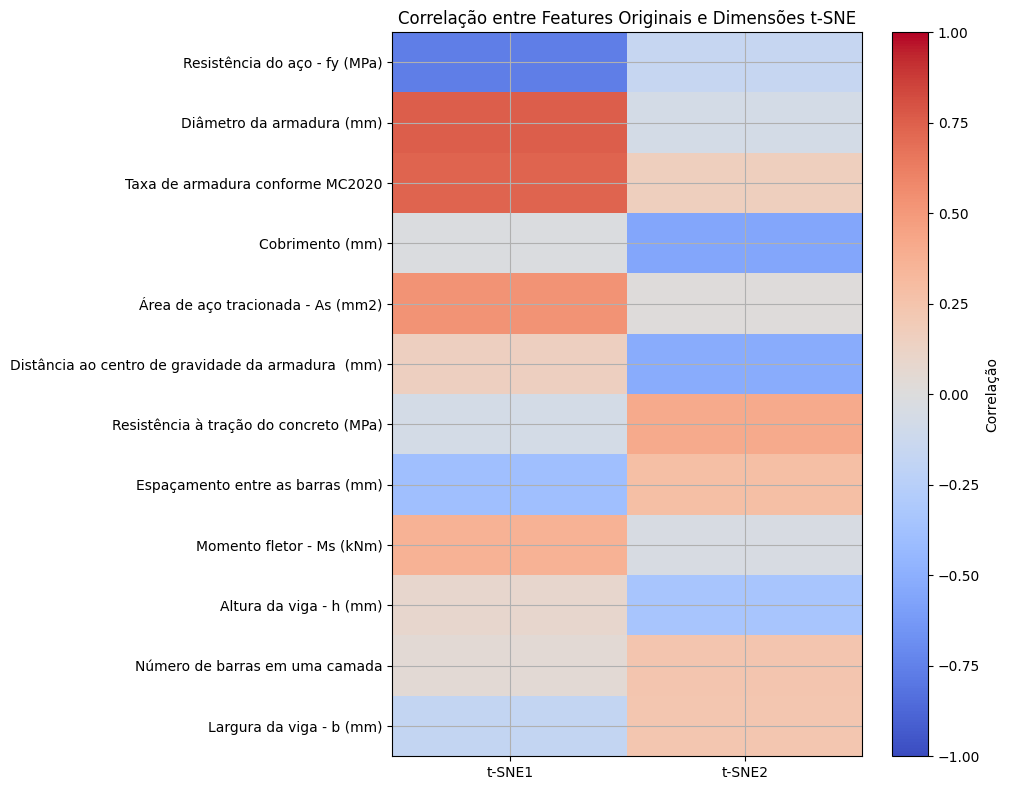

In [17]:
# ==============================
# 2. Heatmap de correlações t-SNE
# ==============================
plt.figure(figsize=(10, 8))
plt.imshow(correlacoes_tsne_sorted[['Corr_TSNE1', 'Corr_TSNE2']].values, 
           aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlação')
plt.yticks(range(len(correlacoes_tsne_sorted)), correlacoes_tsne_sorted.index)
plt.xticks([0, 1], ['t-SNE1', 't-SNE2'])
plt.title('Correlação entre Features Originais e Dimensões t-SNE')
plt.tight_layout()
plt.show()

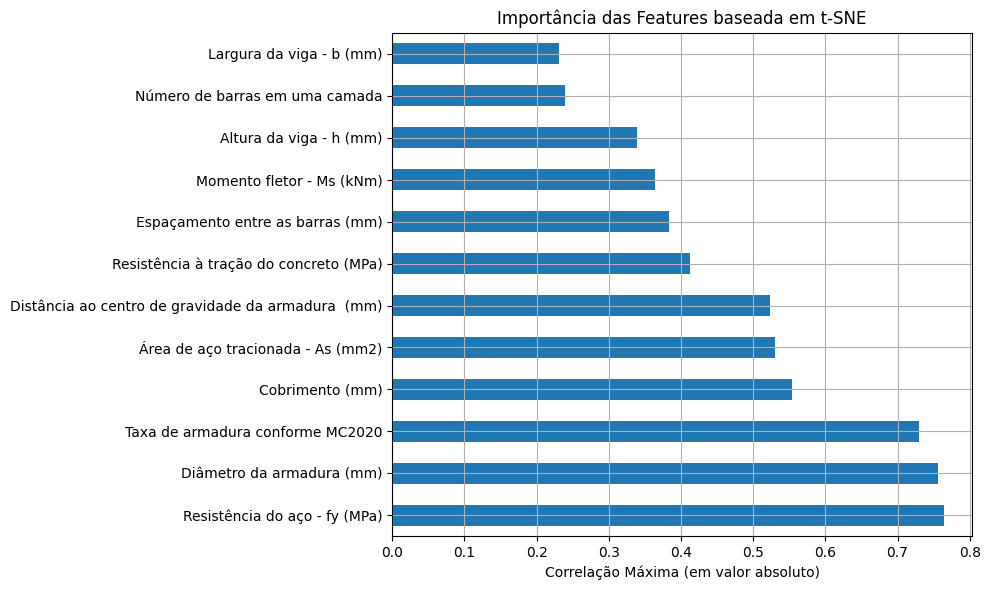

In [18]:
# ==============================
# 3. Gráfico de barras - Importância das features no t-SNE
# ==============================
plt.figure(figsize=(10, 6))
correlacoes_tsne_sorted['Corr_Abs_Max'].plot(kind='barh')
plt.xlabel('Correlação Máxima (em valor absoluto)')
plt.title('Importância das Features baseada em t-SNE')
plt.tight_layout()
plt.show()

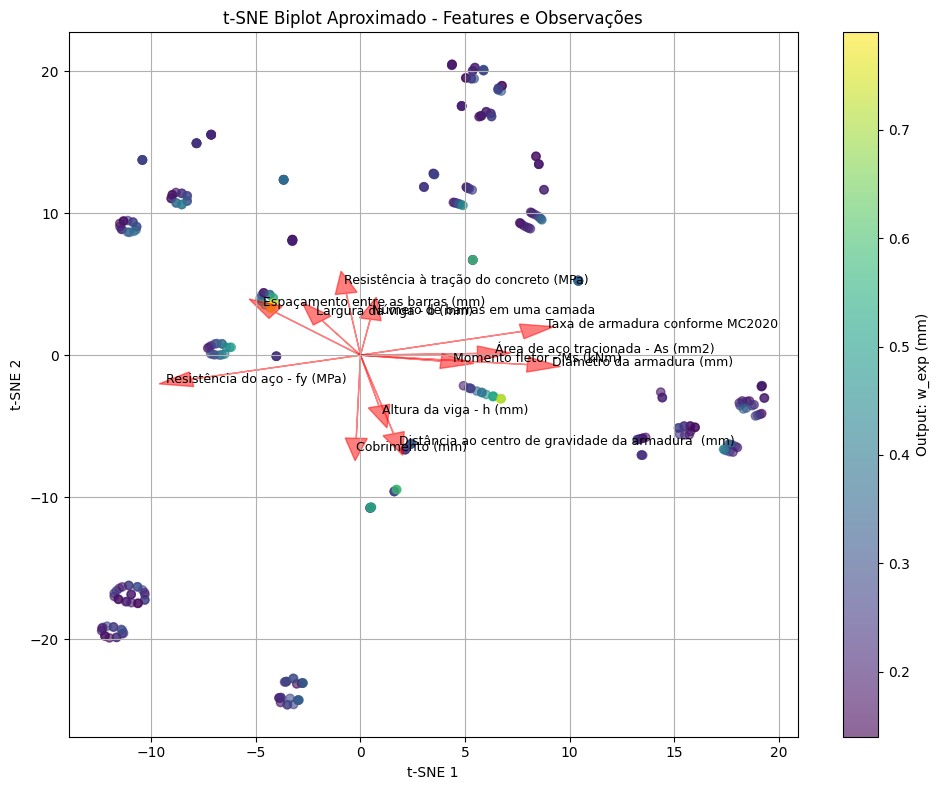

In [19]:
# ==============================
# 4. Biplot aproximado para t-SNE
# ==============================
# Como t-SNE não tem loadings verdadeiros, vamos usar as correlações 
# multiplicadas por um fator de escala para visualização
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)

# Fator de escala para as setas
scale_factor_tsne = (X_tsne[:, 0].max() - X_tsne[:, 0].min()) / 3

# Desenha setas baseadas nas correlações
for i, feature in enumerate(X.columns):
    corr_tsne1 = correlacoes_tsne.loc[feature, 'Corr_TSNE1']
    corr_tsne2 = correlacoes_tsne.loc[feature, 'Corr_TSNE2']
    
    plt.arrow(0, 0, 
              corr_tsne1 * scale_factor_tsne, 
              corr_tsne2 * scale_factor_tsne,
              color='r', alpha=0.5, head_width=scale_factor_tsne*0.1)
    plt.text(corr_tsne1 * scale_factor_tsne * 1.15, 
             corr_tsne2 * scale_factor_tsne * 1.15,
             feature, fontsize=9)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Biplot Aproximado - Features e Observações')
plt.colorbar(label=NOME_COLUNA_ALVO)
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_415015/1561150584.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


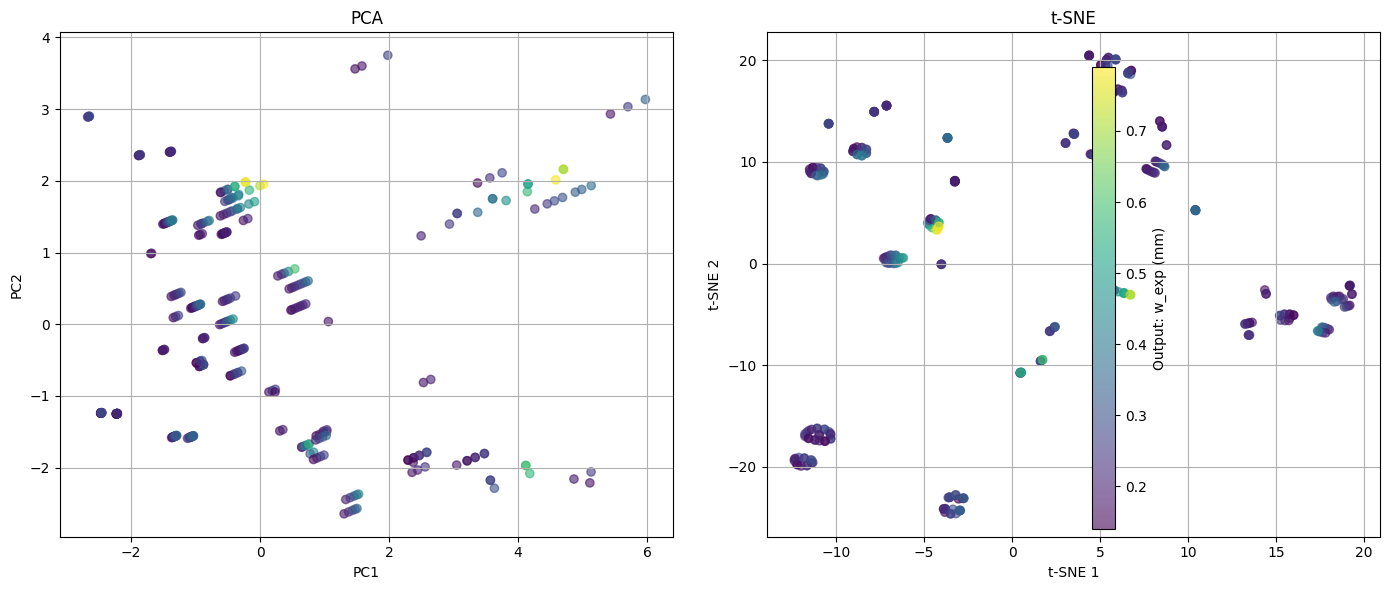

In [20]:
# ==============================
# 5. Comparação lado a lado: PCA vs t-SNE
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA')
axes[0].grid(True)

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE')
axes[1].grid(True)

# Colorbar compartilhada
fig.colorbar(scatter1, ax=axes, label=NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()


=== COMPARAÇÃO DE IMPORTÂNCIAS (NORMALIZADO 0-1) ===
                                                                                              Feature  \
Área de aço tracionada - As (mm2)                                           Momento fletor - Ms (kNm)   
Resistência do aço - fy (MPa)                                                 Altura da viga - h (mm)   
Distância ao centro de gravidade da armadura  (mm)                     Número de barras em uma camada   
Taxa de armadura conforme MC2020                                     Taxa de armadura conforme MC2020   
Largura da viga - b (mm)                                                              Cobrimento (mm)   
Espaçamento entre as barras (mm)                               Resistência à tração do concreto (MPa)   
Diâmetro da armadura (mm)                                            Espaçamento entre as barras (mm)   
Momento fletor - Ms (kNm)                           Distância ao centro de gravidade da armadura  ...   
R

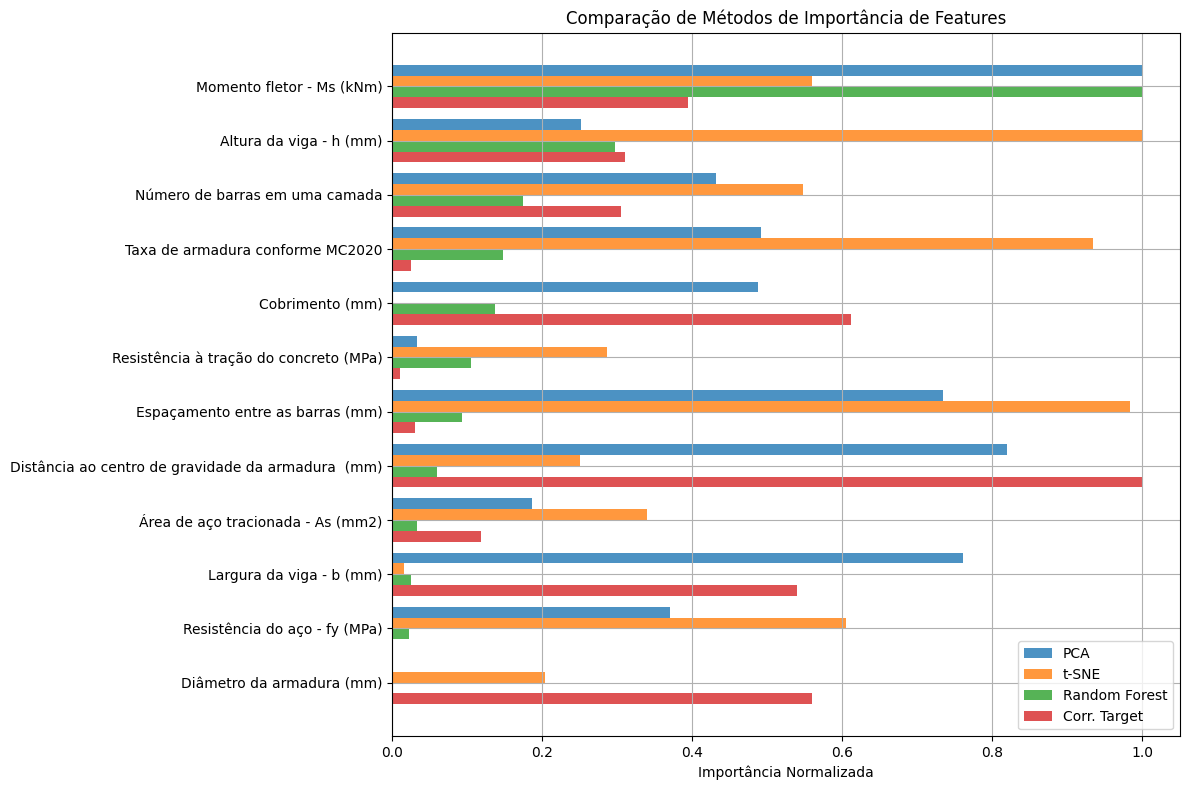

In [21]:
# ==============================
# 6. Comparação de importâncias: PCA vs t-SNE vs Random Forest
# ==============================
comparacao_importancias = pd.DataFrame({
    'Feature': X.columns,
    'PCA_Importance': loadings_df['Importancia_Total'],
    'TSNE_Importance': correlacoes_tsne['Corr_Abs_Max'],
    'RF_Importance': rf.feature_importances_,
    'Target_Correlation': correlacao_target.abs()
})

# Normalizar para comparação (escala 0-1)
for col in ['PCA_Importance', 'TSNE_Importance', 'RF_Importance', 'Target_Correlation']:
    comparacao_importancias[col] = (comparacao_importancias[col] - comparacao_importancias[col].min()) / \
                                    (comparacao_importancias[col].max() - comparacao_importancias[col].min())

comparacao_importancias = comparacao_importancias.sort_values('RF_Importance', ascending=False)

print("\n=== COMPARAÇÃO DE IMPORTÂNCIAS (NORMALIZADO 0-1) ===")
print(comparacao_importancias)

# Plot comparativo
fig, ax = plt.subplots(figsize=(12, 8))
x_pos = np.arange(len(comparacao_importancias))
width = 0.2

ax.barh(x_pos - 1.5*width, comparacao_importancias['PCA_Importance'], width, label='PCA', alpha=0.8)
ax.barh(x_pos - 0.5*width, comparacao_importancias['TSNE_Importance'], width, label='t-SNE', alpha=0.8)
ax.barh(x_pos + 0.5*width, comparacao_importancias['RF_Importance'], width, label='Random Forest', alpha=0.8)
ax.barh(x_pos + 1.5*width, comparacao_importancias['Target_Correlation'], width, label='Corr. Target', alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels(comparacao_importancias['Feature'])
ax.set_xlabel('Importância Normalizada')
ax.set_title('Comparação de Métodos de Importância de Features')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [22]:
# ==============================
# 7. Salvar resultados completos
# ==============================
# Adicionar as análises de correlação ao DataFrame
df_completo = df.copy()
df_completo['Corr_PC1'] = None
df_completo['Corr_PC2'] = None
df_completo['Corr_TSNE1'] = None
df_completo['Corr_TSNE2'] = None

# Salvar tabelas de análise separadamente
with pd.ExcelWriter('analise_completa_pca_tsne.xlsx') as writer:
    df_completo.to_excel(writer, sheet_name='Dados_Completos', index=False)
    loadings_df_sorted.to_excel(writer, sheet_name='PCA_Loadings')
    correlacoes_sorted.to_excel(writer, sheet_name='PCA_Correlacoes')
    correlacoes_tsne_sorted.to_excel(writer, sheet_name='TSNE_Correlacoes')
    feature_importance.to_excel(writer, sheet_name='RF_Importance', index=False)
    comparacao_importancias.to_excel(writer, sheet_name='Comparacao_Metodos', index=False)
    correlacao_target.to_frame('Correlacao').to_excel(writer, sheet_name='Target_Correlation')

print("\nArquivo 'analise_completa_pca_tsne.xlsx' gerado com sucesso!")
print("Contém as seguintes abas:")
print("  - Dados_Completos: dados originais + PCA + t-SNE")
print("  - PCA_Loadings: loadings do PCA")
print("  - PCA_Correlacoes: correlações das features com PCs")
print("  - TSNE_Correlacoes: correlações das features com dimensões t-SNE")
print("  - RF_Importance: importâncias do Random Forest")
print("  - Comparacao_Metodos: comparação de todos os métodos")
print("  - Target_Correlation: correlação direta com target")


Arquivo 'analise_completa_pca_tsne.xlsx' gerado com sucesso!
Contém as seguintes abas:
  - Dados_Completos: dados originais + PCA + t-SNE
  - PCA_Loadings: loadings do PCA
  - PCA_Correlacoes: correlações das features com PCs
  - TSNE_Correlacoes: correlações das features com dimensões t-SNE
  - RF_Importance: importâncias do Random Forest
  - Comparacao_Metodos: comparação de todos os métodos
  - Target_Correlation: correlação direta com target
